In [6]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Exploratory Data Analysis  
- Load in the cleaned data

In [17]:
df = pd.read_csv('/content/AviationData.csv', encoding='latin1')

/tmp/ipykernel_2113/3304722569.py:1: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/AviationData.csv', encoding='latin1')


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types.

In [18]:
df['Event.Date'] = pd.to_datetime(df['Event.Date'])
df = df[df['Event.Date'].dt.year >= 1983].copy()

In [20]:

injury_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']

found_cols = [c for c in df.columns if any(x in c for x in ['Fatal', 'Serious', 'Minor', 'Uninjured'])]
df['Total_Occupants'] = df[found_cols].fillna(0).sum(axis=1).replace(0, 1)

In [21]:
fatal = df['Total.Fatal.Injuries'].fillna(0) if 'Total.Fatal.Injuries' in df else 0
serious = df['Total.Serious.Injuries'].fillna(0) if 'Total.Serious.Injuries' in df else 0

In [23]:
df['Injury_Fraction'] = (fatal + serious) / df['Total_Occupants']

In [25]:
if 'Aircraft.Damage' in df.columns:
    df['Is_Destroyed'] = (df['Aircraft.Damage'].str.upper() == 'DESTROYED').astype(int)
else:
    print("Warning: Could not find Aircraft Damage column. Check df.columns output.")

small_planes = df[df['Total_Occupants'] < 20].copy()
large_planes = df[df['Total_Occupants'] >= 20].copy()

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [34]:

df.columns = df.columns.str.strip().str.replace(' ', '.')

df['Event.Date'] = pd.to_datetime(df['Event.Date'])
df = df[df['Event.Date'].dt.year >= 1983].copy()

injury_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
existing_cols = [c for c in injury_cols if c in df.columns]
df['Total_Occupants'] = df[existing_cols].fillna(0).sum(axis=1).replace(0, 1)

fatal = df['Total.Fatal.Injuries'].fillna(0) if 'Total.Fatal.Injuries' in df.columns else 0
serious = df['Total.Serious.Injuries'].fillna(0) if 'Total.Serious.Injuries' in df.columns else 0
df['Injury_Fraction'] = (fatal + serious) / df['Total_Occupants']

damage_col = [c for c in df.columns if 'damage' in c.lower()]
if damage_col:
    df['Is_Destroyed'] = (df[damage_col[0]].astype(str).str.upper() == 'DESTROYED').astype(int)
else:
    raise KeyError("Could not find an Aircraft Damage column in your dataset.")
small_planes = df[df['Total_Occupants'] < 20].copy()
large_planes = df[df['Total_Occupants'] >= 20].copy()


small_makes_summary = (
    small_planes.groupby('Make')
    .filter(lambda x: len(x) >= 10)
    .groupby('Make')
    .agg(mean_injury=('Injury_Fraction', 'mean'), destroyed_rate=('Is_Destroyed', 'mean'))
    .reset_index()
)

large_makes_summary = (
    large_planes.groupby('Make')
    .filter(lambda x: len(x) >= 10)
    .groupby('Make')
    .agg(mean_injury=('Injury_Fraction', 'mean'), destroyed_rate=('Is_Destroyed', 'mean'))
    .reset_index()
)

# 8. Top 15 Makes with lowest mean fatal/serious injury fractions
top15_small_injury = small_makes_summary.nsmallest(15, 'mean_injury')
top15_large_injury = large_makes_summary.nsmallest(15, 'mean_injury')

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

/tmp/ipykernel_2113/1102922627.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15_small_injury, x='mean_injury', y='Make', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_2113/1102922627.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15_large_injury, x='mean_injury', y='Make', ax=axes[1], palette='Greens_r')


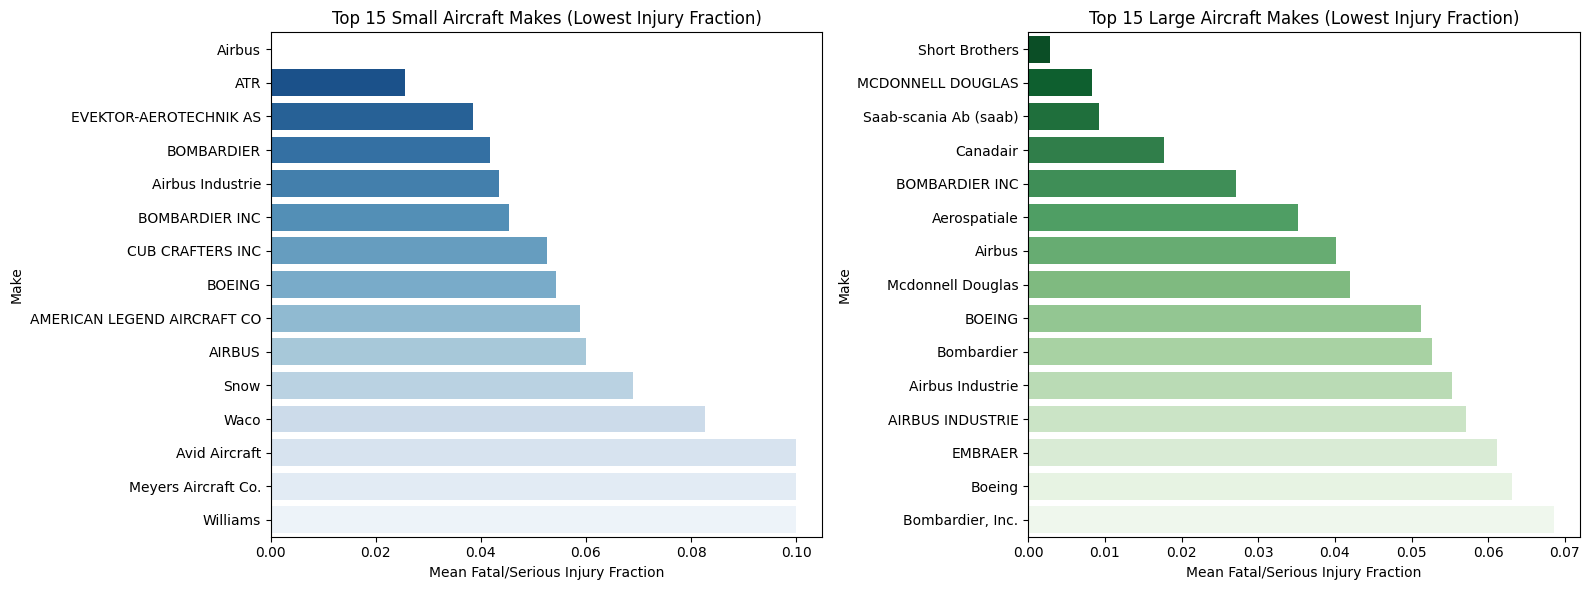

In [35]:
top15_small_injury = small_makes_summary.nsmallest(15, 'mean_injury')
top15_large_injury = large_makes_summary.nsmallest(15, 'mean_injury')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top15_small_injury, x='mean_injury', y='Make', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 15 Small Aircraft Makes (Lowest Injury Fraction)')
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')

sns.barplot(data=top15_large_injury, x='mean_injury', y='Make', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 15 Large Aircraft Makes (Lowest Injury Fraction)')
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

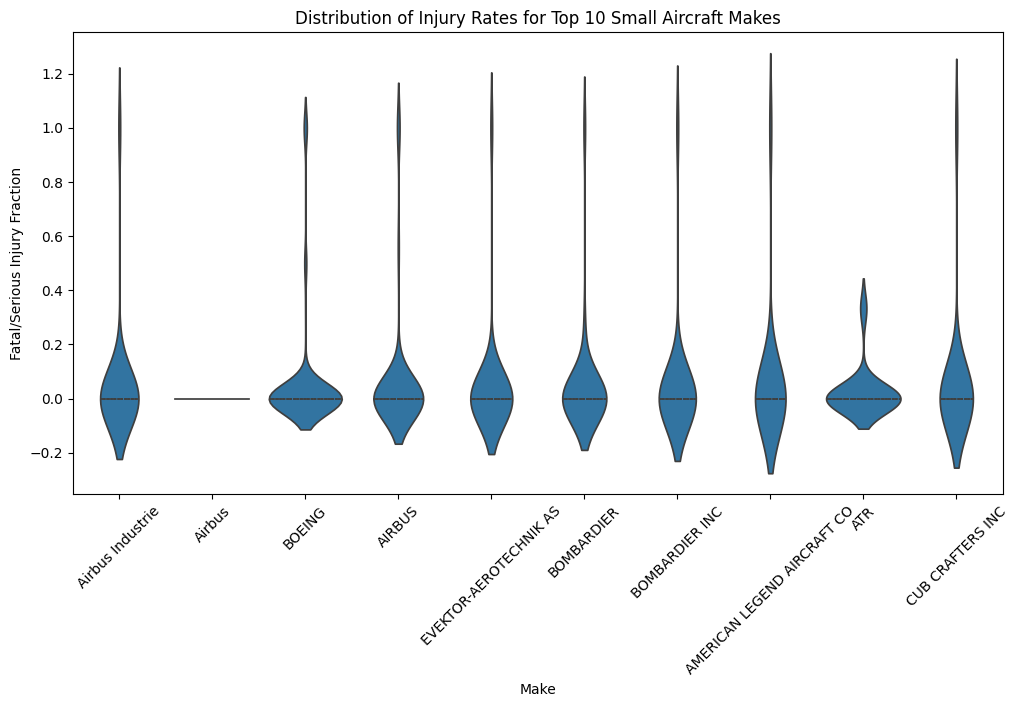

In [36]:
top10_small_makes = top15_small_injury.nsmallest(10, 'mean_injury')['Make']
df_top10_small = small_planes[small_planes['Make'].isin(top10_small_makes)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_top10_small, x='Make', y='Injury_Fraction', inner='quartile')
plt.title('Distribution of Injury Rates for Top 10 Small Aircraft Makes')
plt.xticks(rotation=45)
plt.ylabel('Fatal/Serious Injury Fraction')
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.**

Sort your results and keep the lowest 15.

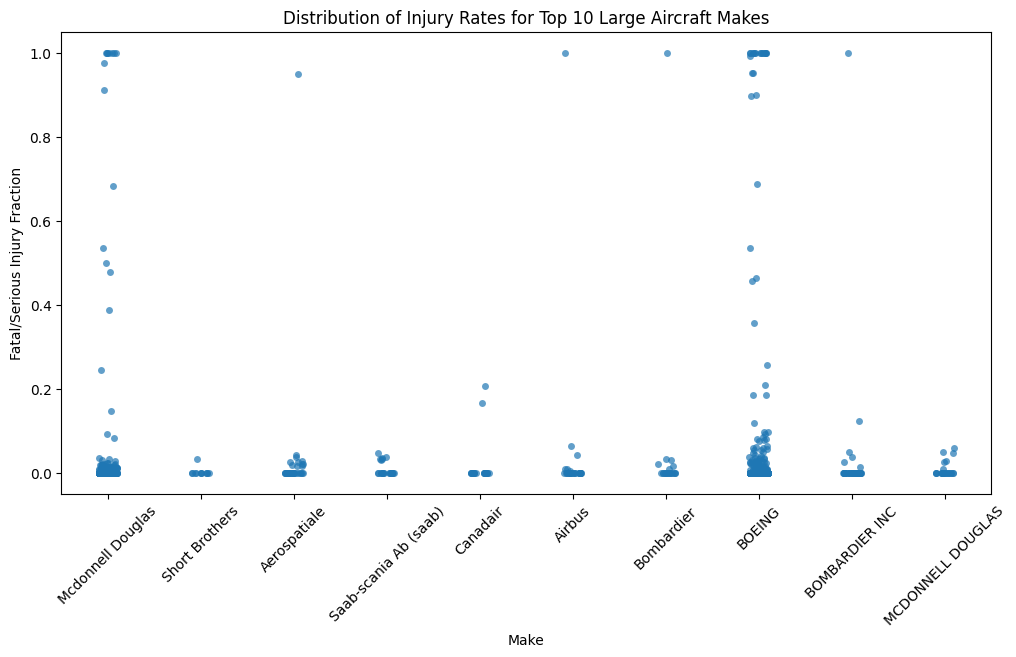

In [37]:
top10_large_makes = top15_large_injury.nsmallest(10, 'mean_injury')['Make']
df_top10_large = large_planes[large_planes['Make'].isin(top10_large_makes)]

plt.figure(figsize=(12, 6))
sns.stripplot(data=df_top10_large, x='Make', y='Injury_Fraction', jitter=True, alpha=0.7)
plt.title('Distribution of Injury Rates for Top 10 Large Aircraft Makes')
plt.xticks(rotation=45)
plt.ylabel('Fatal/Serious Injury Fraction')
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [38]:
top15_small_destroyed = small_makes_summary.nsmallest(15, 'destroyed_rate')
top15_large_destroyed = large_makes_summary.nsmallest(15, 'destroyed_rate')

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

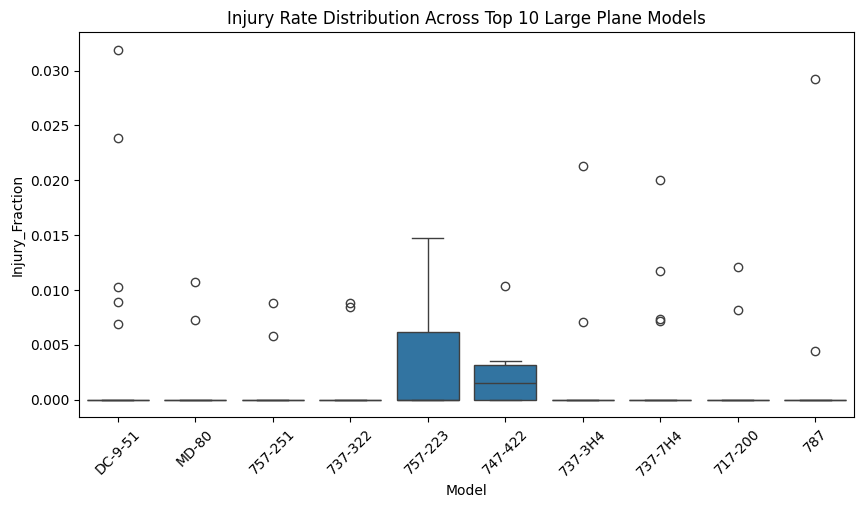

In [39]:
large_models = (
    large_planes.groupby('Model')
    .filter(lambda x: len(x) >= 10)
)
small_models = (
    small_planes.groupby('Model')
    .filter(lambda x: len(x) >= 10)
)

# Plotting top 10 lowest injury models for Large Planes
top10_large_models = (
    large_models.groupby('Model')['Injury_Fraction']
    .mean()
    .nsmallest(10)
    .index
)
plt.figure(figsize=(10, 5))
sns.boxplot(data=large_models[large_models['Model'].isin(top10_large_models)], x='Model', y='Injury_Fraction')
plt.title('Injury Rate Distribution Across Top 10 Large Plane Models')
plt.xticks(rotation=45)
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

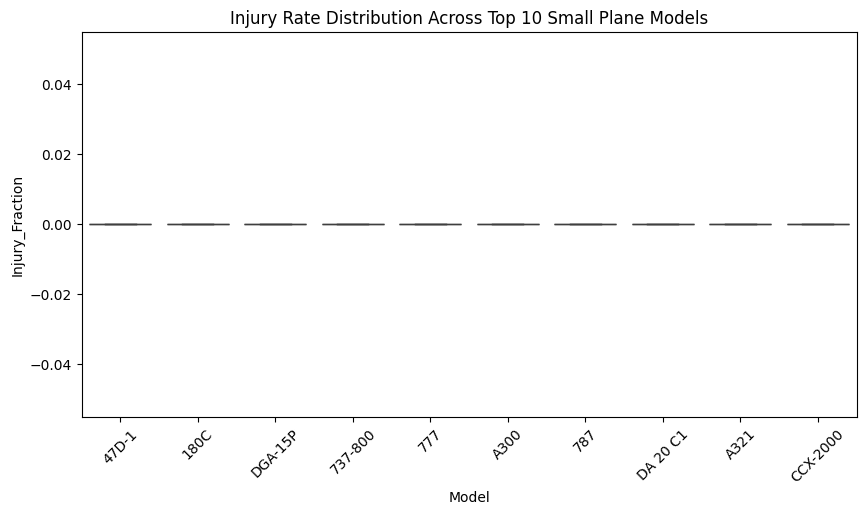

In [40]:
top10_small_models = (
    small_models.groupby('Model')['Injury_Fraction']
    .mean()
    .nsmallest(10)
    .index
)
plt.figure(figsize=(10, 5))
sns.boxplot(data=small_models[small_models['Model'].isin(top10_small_models)], x='Model', y='Injury_Fraction')
plt.title('Injury Rate Distribution Across Top 10 Small Plane Models')
plt.xticks(rotation=45)
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

/tmp/ipykernel_2113/603759381.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Weather.Condition', y='Injury_Fraction', ci=None)


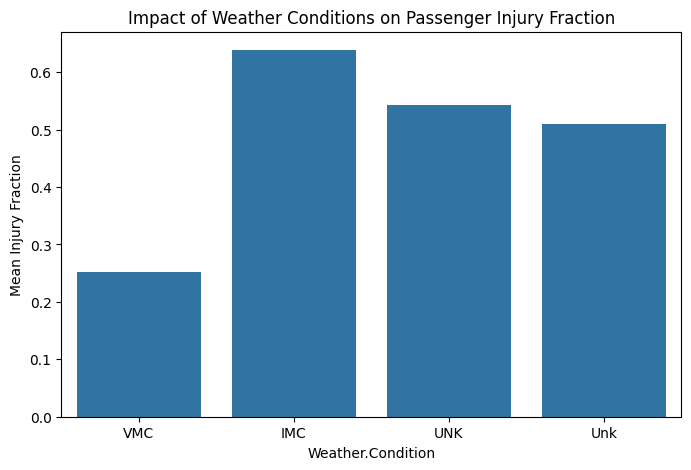

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Weather.Condition', y='Injury_Fraction', ci=None)
plt.title('Impact of Weather Conditions on Passenger Injury Fraction')
plt.ylabel('Mean Injury Fraction')
plt.show()

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

/tmp/ipykernel_2113/2885158814.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Broad.phase.of.flight', y='Is_Destroyed', ci=None)


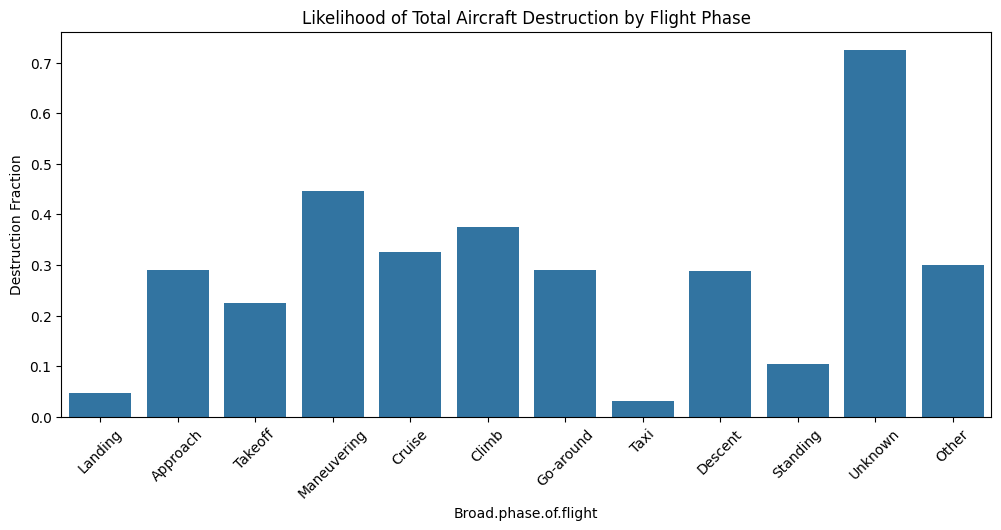

In [42]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='Broad.phase.of.flight', y='Is_Destroyed', ci=None)
plt.title('Likelihood of Total Aircraft Destruction by Flight Phase')
plt.xticks(rotation=45)
plt.ylabel('Destruction Fraction')
plt.show()